In [25]:
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt
import datetime
import numpy as np
import exchange_calendars as xcals

In [18]:
aapl= yf.Ticker("aapl")
aapl

aapl_historical = aapl.history(start="2026-06-01", end="2026-06-17", interval="5m")
aapl_historical

,Open,High,Low,Close,Volume,Dividends,Stock Splits
Datetime,,,,,,,
2026-06-01 09:30:00-04:00,309.535004,310.679993,308.500000,310.029999,3861073,0.0,0.0
2026-06-01 09:35:00-04:00,310.010010,310.929993,309.589996,309.879913,717238,0.0,0.0
2026-06-01 09:40:00-04:00,309.850006,310.100006,309.160004,309.525513,633466,0.0,0.0
2026-06-01 09:45:00-04:00,309.549988,310.299988,309.279999,310.119995,575764,0.0,0.0
2026-06-01 09:50:00-04:00,310.149994,310.619995,309.339996,309.399994,631506,0.0,0.0
...,...,...,...,...,...,...,...
2026-06-16 15:35:00-04:00,298.399994,298.599915,298.350006,298.565002,262941,0.0,0.0
2026-06-16 15:40:00-04:00,298.559998,298.714996,298.489990,298.570007,264710,0.0,0.0
2026-06-16 15:45:00-04:00,298.570007,299.010010,298.549988,299.010010,717068,0.0,0.0


In [22]:
aapl_historical.isna().sum()

Open            0
High            0
Low             0
Close           0
Volume          0
Dividends       0
Stock Splits    0
dtype: int64

In [26]:
nyse = xcals.get_calendar("XNYS")

In [32]:
df_cleaned = aapl_historical.reset_index()
df_cleaned['Date'] = df_cleaned['Date'].dt.strftime('%Y-%m-%d')

KeyError: 'Date'

In [27]:
valid_days = aapl_historical.index.isin(nyse.valid_days)
df_cleaned = aapl_historical[valid_days]

AttributeError: 'XNYSExchangeCalendar' object has no attribute 'valid_days'

In [ ]:
plt.plot(df_cleaned.index, df_cleaned['Close'])
plt.xticks(rotation = 45, ha = 'right')
plt.show();

In [13]:
aapl.history(period='1mo')

,Open,High,Low,Close,Volume,Dividends,Stock Splits
Date,,,,,,,
2026-05-18 00:00:00-04:00,300.239990,300.660004,294.910004,297.839996,34483000,0.0,0.0
2026-05-19 00:00:00-04:00,296.970001,300.510010,296.350006,298.970001,42243600,0.0,0.0
2026-05-20 00:00:00-04:00,298.179993,302.799988,298.079987,302.250000,38229800,0.0,0.0
2026-05-21 00:00:00-04:00,301.059998,305.540009,300.399994,304.989990,42965100,0.0,0.0
2026-05-22 00:00:00-04:00,306.119995,311.399994,305.839996,308.820007,43670200,0.0,0.0
2026-05-26 00:00:00-04:00,309.559998,311.820007,307.670013,308.329987,48000500,0.0,0.0
2026-05-27 00:00:00-04:00,308.329987,313.260010,308.299988,310.850006,50430900,0.0,0.0
2026-05-28 00:00:00-04:00,310.679993,312.799988,309.570007,312.510010,48220400,0.0,0.0
2026-05-29 00:00:00-04:00,311.779999,315.000000,309.529999,312.059998,70026800,0.0,0.0


In [14]:
aapl_historical['log_return'] = np.log(aapl_historical['Close'] / aapl_historical['Close'].shift(1))


In [15]:
aapl_historical

,Open,High,Low,Close,Volume,Dividends,Stock Splits,log_return
Datetime,,,,,,,,
2026-06-01 09:30:00-04:00,309.535004,310.679993,308.500000,310.029999,3861073,0.0,0.0,NaN
2026-06-01 09:35:00-04:00,310.010010,310.929993,309.589996,309.879913,717238,0.0,0.0,-0.000484
2026-06-01 09:40:00-04:00,309.850006,310.100006,309.160004,309.525513,633466,0.0,0.0,-0.001144
2026-06-01 09:45:00-04:00,309.549988,310.299988,309.279999,310.119995,575764,0.0,0.0,0.001919
2026-06-01 09:50:00-04:00,310.149994,310.619995,309.339996,309.399994,631506,0.0,0.0,-0.002324
...,...,...,...,...,...,...,...,...
2026-06-16 15:35:00-04:00,298.399994,298.599915,298.350006,298.565002,262941,0.0,0.0,0.000570
2026-06-16 15:40:00-04:00,298.559998,298.714996,298.489990,298.570007,264710,0.0,0.0,0.000017
2026-06-16 15:45:00-04:00,298.570007,299.010010,298.549988,299.010010,717068,0.0,0.0,0.001473


In [16]:
aapl_historical.columns

Index(['Open', 'High', 'Low', 'Close', 'Volume', 'Dividends', 'Stock Splits',
       'log_return'],
      dtype='object')

In [50]:
aapl_historical.Datetime['2026-06-05': '2026-06-08']

AttributeError: 'DataFrame' object has no attribute 'Datetime'

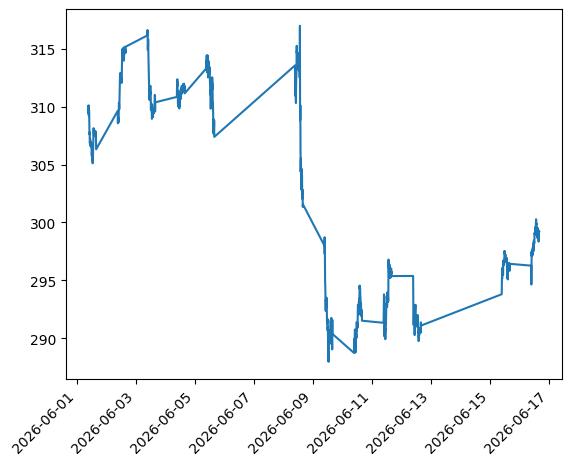

In [17]:
plt.plot(aapl_historical.index, aapl_historical['Close'])
plt.xticks(rotation = 45, ha = 'right')
plt.show();

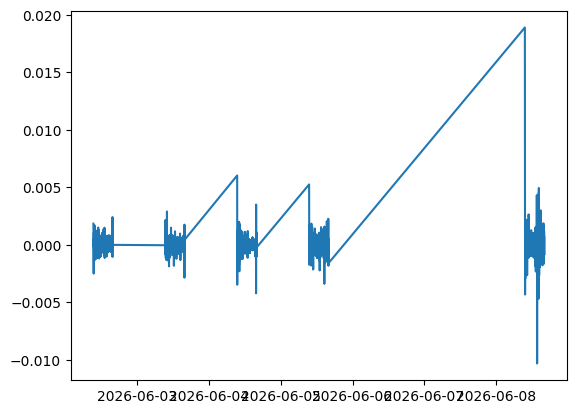

In [49]:
plt.plot(aapl_historical.index, aapl_historical['log_return'])
plt.show();

In [43]:
apple= yf.Ticker("aapl")

# show actions (dividends, splits)
apple.actions

# show dividends
apple.dividends

# show splits
apple.splits

TypeError: 'NoneType' object is not subscriptable

Text(0.5, 1.0, 'Log Return of AAPL Stock')

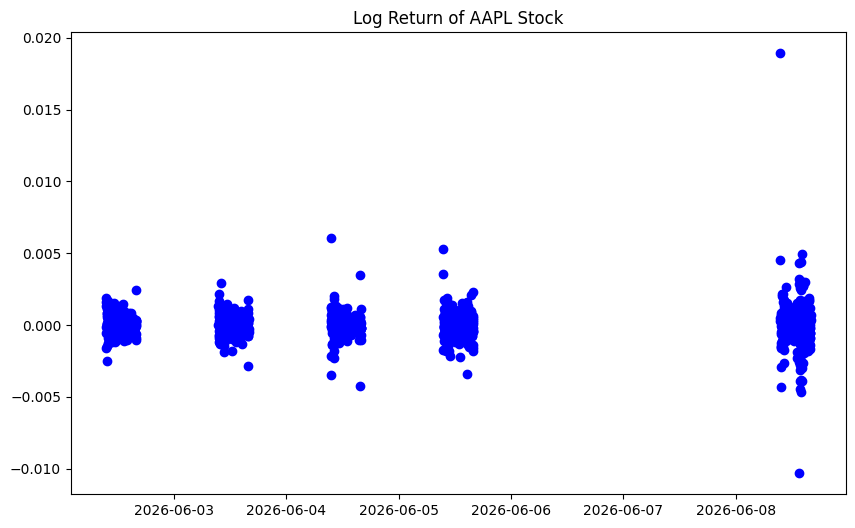

In [ ]:
fig = plt.figure(figsize=(10, 6))
plt.scatter(aapl_historical.index, aapl_historical['log_return'], color='blue', label='Log Return')
plt.title('Log Return of AAPL Stock')